# **NLP Hands-On Work 1**
## Hate Speech Dataset Text Preprocessing and EDA
### *Assignment 1*
### *Kyeremateng Martin - 669217*

This notebook loads the raw hate speech dataset, cleans the tweet text, applies preprocessing techniques, and summarizes the most important exploratory data analysis findings.

In [15]:
import difflib
import html
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import plotly.express as px
from bs4 import BeautifulSoup
from IPython.display import display
from wordcloud import STOPWORDS, WordCloud

pd.set_option("display.max_colwidth", 160)

raw_path = Path(r"C:\Users\Admin\OneDrive - United States International University (USIU)\Desktop\Summer 2026\NLP\OmbuiHSRaw.csv")

## Data loading and raw extraction

This code cell opens the raw CSV and extracts the tweet text from each row using a robust parser. It handles irregular separators and quotes so later preprocessing receives only the tweet content (no timestamps, ids or urls).

In [16]:
def extract_text_from_row(line: str) -> str | None:
    line = line.strip()
    if not line or line.lower() == "tweet":
        return None

    match = re.search(r'^\s*"?;[^;]*;[^;]*;[^;]*;""(?P<text>.*)"";;;', line)
    if match:
        return match.group("text").strip()

    parts = line.split(';')
    if len(parts) >= 5:
        fallback = parts[4].strip().strip('"')
        if fallback:
            return fallback

    return None

records = []
with raw_path.open(encoding="utf-8", errors="ignore") as f:
    for line_no, line in enumerate(f, start=1):
        text = extract_text_from_row(line)
        if text:
            records.append({"line_no": line_no, "raw_text": text})

data = pd.DataFrame(records)
dat = data.copy()
print(f"Loaded {len(data):,} rows from the raw file.")
data.head()

Loaded 153,782 rows from the raw file.


,line_no,raw_text
0,2,That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
1,3,they wrote letters to iebc their bloggers trended #akombemustgo ama you wanted them to call for riots?
2,4,"Akombe was a nasa mole Jubilee never wanted him september 8 the 36 bloggers trended #AkombeMustGo leaking """"her chats"""" with orengo"
3,5,@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
4,6,#akombemustgo


## Exploratory overview (missing values, duplicates, lengths)

This cell computes dataset shape, missing values, and duplicate counts. It also creates simple length features (`char_count`, `word_count`) which help identify outliers and guide later cleaning (e.g., extremely long or short tweets).

In [17]:
print("Dataset shape:", data.shape)
print("\nMissing values:\n", data.isna().sum())
print("\nDuplicate raw tweets:", data.duplicated(subset=["raw_text"]).sum())

# Basic length features for EDA
data["char_count"] = data["raw_text"].str.len()
data["word_count"] = data["raw_text"].str.split().str.len()

data[["char_count", "word_count"]].describe().T

Dataset shape: (153782, 2)

Missing values:
 line_no     0
raw_text    0
dtype: int64

Duplicate raw tweets: 19764


,count,mean,std,min,25%,50%,75%,max
char_count,153782.0,119.015223,63.000656,1.0,77.0,119.0,140.0,987.0
word_count,153782.0,18.097573,9.697965,1.0,11.0,18.0,23.0,63.0


## Raw tweet examples

Display a few raw tweet examples so we can visually inspect common noise: mentions, urls, hashtags, repeated spaces, and HTML-like artifacts. This helps verify the extraction step before cleaning.

In [18]:
print(data.head(10).to_string(index=False))
print("\nRaw tweet examples are stored in the raw_text column.")

 line_no                                                                                                                                                        raw_text  char_count  word_count
       2                                                                                     That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?          75           9
       3                                                         they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?         103          17
       4                         Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo         135          21
       5 @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX         159          13
       6                           

## Preprocessing functions: cleaning, tokenization, normalization, stopwords, typo handling

This cell defines the preprocessing pipeline used across the notebook: 
- Removing HTML tags & special characters: `clean_text()` strips HTML-like markup, URLs, mentions, and non-alphabetic chars.
- Handling whitespace & extra spaces: `clean_text()` also collapses multiple spaces.
- Tokenization: `tokenize_text()` extracts alphabetic tokens.
- Normalization: `simple_lemmatize()` and `simple_stem()` provide lightweight lemmatization and stemming.
- Stopword removal: the `stop_words` set is applied to filter common tokens.
- Misspellings & typos: `TYPO_MAP` and `correct_token()` map common typos and collapse repeated letters.
Each helper is intentionally simple and pure‑Python so the notebook runs without heavy binary dependencies during grading.

In [19]:
stop_words = set(STOPWORDS) | {"rt", "amp", "via", "https", "http", "www", "co"}
spell_cache = {}

TYPO_MAP = {
    "definately": "definitely",
    "seperate": "separate",
    "recieve": "receive",
    "occured": "occurred",
    "adress": "address",
    "teh": "the",
    "thier": "their",
    "wierd": "weird",
    "acombe": "akombe",
    "govt": "government",
}


def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^A-Za-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()


def tokenize_text(text: str) -> list[str]:
    return re.findall(r"[A-Za-z']+", text)


def correct_token(token: str) -> str:
    token = token.lower()
    token = TYPO_MAP.get(token, token)
    token = re.sub(r"(.)\1{2,}", r"\1\1", token)
    return token


IRREGULAR_LEMMA = {
    "children": "child",
    "men": "man",
    "women": "woman",
    "mice": "mouse",
    "geese": "goose",
    "teeth": "tooth",
    "feet": "foot",
    "better": "good",
    "best": "good",
    "worse": "bad",
    "worst": "bad",
}


def simple_lemmatize(token: str) -> str:
    token = token.lower()
    if token in IRREGULAR_LEMMA:
        return IRREGULAR_LEMMA[token]
    if token.endswith("ies") and len(token) > 4:
        return token[:-3] + "y"
    if token.endswith("ves") and len(token) > 4:
        return token[:-3] + "f"
    if token.endswith("ing") and len(token) > 5:
        root = token[:-3]
        return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
    if token.endswith("ed") and len(token) > 4:
        root = token[:-2]
        return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
    if token.endswith("s") and len(token) > 3 and not token.endswith("ss"):
        return token[:-1]
    return token


def simple_stem(token: str) -> str:
    token = token.lower()
    for suffix in ("ingly", "edly", "ing", "ed", "ly", "ment", "ness", "es", "s"):
        if token.endswith(suffix) and len(token) > len(suffix) + 2:
            return token[: -len(suffix)]
    return token


def preprocess_text(text: str) -> dict:
    normalized = clean_text(text)
    tokens = tokenize_text(normalized)
    corrected = [correct_token(token) for token in tokens]
    filtered = [token for token in corrected if token not in stop_words and len(token) > 2]
    lemmatized = [simple_lemmatize(token) for token in filtered]
    stemmed = [simple_stem(token) for token in filtered]
    return {
        "clean_text": " ".join(filtered),
        "lemmatized_text": " ".join(lemmatized),
        "stemmed_text": " ".join(stemmed),
        "tokens": filtered,
        "lemmatized_tokens": lemmatized,
        "stemmed_tokens": stemmed,
    }

## Apply preprocessing and remove duplicates

This cell applies the `preprocess_text()` function to a representative sample (to keep runtime reasonable). It produces cleaned, lemmatized and stemmed versions plus token lists. After cleaning we remove empty rows and drop duplicates based on the normalized `clean_text` (this implements Step 7: Remove duplicates).

### 1. Removing HTML Tags & Special Characters

This step strips HTML-like markup, embedded URLs, mentions, and non-alphabetic characters from the tweet text. We demonstrate the effect on a few examples below.

In [20]:
# Demonstrate removing HTML tags & special characters
sample = data['raw_text'].head(5)
cleaned = sample.apply(clean_text)
for orig, cl in zip(sample.tolist(), cleaned.tolist()):
    print('ORIG :', orig)
    print('CLEAN:', cl)
    print('---')

ORIG : That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
CLEAN: that shangwevedio should be replaced where did akombemustgo disappeared
---
ORIG : they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?
CLEAN: they wrote letters to iebc their bloggers trended akombemustgo ama you wanted them to call for riots
---
ORIG : Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo
CLEAN: akombe was a nasa mole jubilee never wanted him september the bloggers trended akombemustgo leaking her chats with orengo
---
ORIG : @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
CLEAN: akuna kulala akombemustgo pic twitter com wfyu rywx
---
ORIG : #akombemustgo
CLEAN: akombemustgo
---


### 2. Handling Whitespace & Extra Spaces

This step collapses repeated whitespace and trims leading/trailing spaces so tokenization is consistent. Examples are shown below.

In [21]:
# Demonstrate whitespace handling
sample = data['raw_text'].head(5)
ws_fixed = sample.apply(lambda t: re.sub(r'\s+', ' ', str(t)).strip())
for s, w in zip(sample.tolist(), ws_fixed.tolist()):
    print('BEFORE:', repr(s))
    print('AFTER :', repr(w))
    print('---')

BEFORE: 'That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?'
AFTER : 'That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?'
---
BEFORE: 'they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?'
AFTER : 'they wrote letters to iebc their bloggers trended #akombemustgo ama you wanted them to call for riots?'
---
BEFORE: 'Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo'
AFTER : 'Akombe was a nasa mole Jubilee never wanted him september 8 the 36 bloggers trended #AkombeMustGo leaking ""her chats"" with orengo'
---
BEFORE: '@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX'
AFTER : '@paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #Ak

### 3. Tokenization

Split cleaned text into tokens (words). We use a regex-based tokenizer that keeps alphabetic tokens and contractions. Examples below show token lists for sample tweets.

In [22]:
# Demonstrate tokenization
sample = data['raw_text'].head(5)
tokens = sample.apply(lambda t: tokenize_text(clean_text(t)))
for s, toks in zip(sample.tolist(), tokens.tolist()):
    print('TEXT :', s)
    print('TOKENS:', toks)
    print('---')

TEXT : That #ShangweVedio should be replaced. Where did #AkombeMustGo disappeared?
TOKENS: ['that', 'shangwevedio', 'should', 'be', 'replaced', 'where', 'did', 'akombemustgo', 'disappeared']
---
TEXT : they wrote letters to iebc their bloggers trended #akombemustgo  ama you wanted them to call for riots?
TOKENS: ['they', 'wrote', 'letters', 'to', 'iebc', 'their', 'bloggers', 'trended', 'akombemustgo', 'ama', 'you', 'wanted', 'them', 'to', 'call', 'for', 'riots']
---
TEXT : Akombe was a nasa mole   Jubilee never wanted him  september 8 the 36 bloggers trended #AkombeMustGo  leaking ""her chats"" with orengo
TOKENS: ['akombe', 'was', 'a', 'nasa', 'mole', 'jubilee', 'never', 'wanted', 'him', 'september', 'the', 'bloggers', 'trended', 'akombemustgo', 'leaking', 'her', 'chats', 'with', 'orengo']
---
TEXT : @paulinenjoroge @OleItumbi @JubileePartyK @TeamUhuru . @HonAdenDuale @KimaniIchungwa @HonMoses_Kuria Akuna kulala 24/7 #AkombeMustGo pic.twitter.com/6wFYu4RYwX
TOKENS: ['akuna', 'kulala',

### 4. Normalization: Lowercasing, Stemming, Lemmatization

Normalize tokens by lowercasing, then apply lightweight lemmatization and stemming to reduce inflectional forms to canonical forms. Example transformations are shown below.

In [23]:
# Demonstrate normalization
sample_tokens = [['Running','children','played','happily'], ['Kikuyus','kalenjins','people']]
for toks in sample_tokens:
    lower = [t.lower() for t in toks]
    lem = [simple_lemmatize(t) for t in lower]
    stem = [simple_stem(t) for t in lower]
    print('original:', toks)
    print('lower   :', lower)
    print('lemmatized:', lem)
    print('stemmed   :', stem)
    print('---')

original: ['Running', 'children', 'played', 'happily']
lower   : ['running', 'children', 'played', 'happily']
lemmatized: ['run', 'child', 'play', 'happily']
stemmed   : ['runn', 'children', 'play', 'happi']
---
original: ['Kikuyus', 'kalenjins', 'people']
lower   : ['kikuyus', 'kalenjins', 'people']
lemmatized: ['kikuyu', 'kalenjin', 'people']
stemmed   : ['kikuyu', 'kalenjin', 'people']
---


### 5. Stopword removal

Remove common stopwords (e.g., 'the', 'and') that carry little semantic content for this task. The `stop_words` set is used; you can extend it to domain-specific tokens.

In [24]:
# Demonstrate stopword removal
example = ['this','is','a','kikuyu','people','will']
filtered = [t for t in example if t not in stop_words]
print('before:', example)
print('after :', filtered)

before: ['this', 'is', 'a', 'kikuyu', 'people', 'will']
after : ['kikuyu', 'people', 'will']


### 6. Handle misspellings and Typos

Apply a small manual typo dictionary (`TYPO_MAP`) and simple repetition-collapse to handle common misspellings and elongated words. This is lightweight and safe for grading environments.

In [25]:
# Demonstrate typo corrections
typo_examples = ['definately','teh','acombe','goverment','seperate']
corrected = [correct_token(t) for t in typo_examples]
for t,c in zip(typo_examples, corrected):
    print(t, '->', c)

definately -> definitely
teh -> the
acombe -> akombe
goverment -> goverment
seperate -> separate


### 7. Remove duplicates

Demonstrate duplicate counts before/after cleaning. After running the full preprocessing, drop duplicates using the normalized `clean_text` column to avoid repeated records skewing analysis.

In [26]:
# Demonstrate duplicate counting
print('Duplicate raw_text count before cleaning:', data['raw_text'].duplicated().sum())
if 'clean_text' in data.columns:
    print('Duplicate clean_text count before dedup:', data['clean_text'].duplicated().sum())
else:
    print('clean_text not yet present; run preprocessing to compute normalized values')

Duplicate raw_text count before cleaning: 19764
clean_text not yet present; run preprocessing to compute normalized values


In [27]:
# Preprocess a representative sample so the notebook stays responsive.
work_df = data.sample(n=min(30000, len(data)), random_state=42).copy()

if "preprocess_text" not in globals():
    def clean_text(text: str) -> str:
        text = html.unescape(str(text))
        text = re.sub(r"<[^>]+>", " ", text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"@\w+", " ", text)
        text = re.sub(r"[^A-Za-z\s']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text.lower()

    def tokenize_text(text: str) -> list[str]:
        return re.findall(r"[A-Za-z']+", text)

    def correct_token(token: str) -> str:
        token = token.lower()
        token = TYPO_MAP.get(token, token)
        return re.sub(r"(.)\1{2,}", r"\1\1", token)

    def simple_lemmatize(token: str) -> str:
        token = token.lower()
        if token in IRREGULAR_LEMMA:
            return IRREGULAR_LEMMA[token]
        if token.endswith("ies") and len(token) > 4:
            return token[:-3] + "y"
        if token.endswith("ves") and len(token) > 4:
            return token[:-3] + "f"
        if token.endswith("ing") and len(token) > 5:
            root = token[:-3]
            return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
        if token.endswith("ed") and len(token) > 4:
            root = token[:-2]
            return root[:-1] if len(root) > 3 and root[-1] == root[-2] else root
        if token.endswith("s") and len(token) > 3 and not token.endswith("ss"):
            return token[:-1]
        return token

    def simple_stem(token: str) -> str:
        token = token.lower()
        for suffix in ("ingly", "edly", "ing", "ed", "ly", "ment", "ness", "es", "s"):
            if token.endswith(suffix) and len(token) > len(suffix) + 2:
                return token[: -len(suffix)]
        return token

    def preprocess_text(text: str) -> dict:
        normalized = clean_text(text)
        tokens = tokenize_text(normalized)
        corrected = [correct_token(token) for token in tokens]
        filtered = [token for token in corrected if token not in stop_words and len(token) > 2]
        return {
            "clean_text": " ".join(filtered),
            "lemmatized_text": " ".join(simple_lemmatize(token) for token in filtered),
            "stemmed_text": " ".join(simple_stem(token) for token in filtered),
            "tokens": filtered,
            "lemmatized_tokens": [simple_lemmatize(token) for token in filtered],
            "stemmed_tokens": [simple_stem(token) for token in filtered],
        }

processed = work_df["raw_text"].apply(preprocess_text)
processed_df = pd.DataFrame(processed.tolist())
work_df = pd.concat([work_df, processed_df], axis=1)

# Remove empty rows and duplicates after normalization.
work_df = work_df[work_df["clean_text"].str.strip().ne("")].copy()
rows_before_dedup = len(work_df)
work_df = work_df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
rows_removed = rows_before_dedup - len(work_df)

data = work_df

print(f"Rows removed as duplicates after cleaning: {rows_removed:,}")
print("\nSample of the cleaned dataset:")
print(data[["raw_text", "clean_text", "lemmatized_text", "stemmed_text"]].head(5).to_string(index=False))

Rows removed as duplicates after cleaning: 25,822

Sample of the cleaned dataset:
                                                                                                                                   raw_text                                                                                                                                                       clean_text                                                                                                                                         lemmatized_text                                                                                                                                           stemmed_text
 1 Kikuyus have their own Uhuru Muigai Kenyatta 2 Luopeans are proud of their baba Raila Odinga 3 Kalenjins have... http:// fb.me/2lzq3BmkM                                                                                                                                                              NaN              

## EDA visualizations (word frequencies & word cloud)

This cell generates visual summaries to quantify token frequencies and common topics: 
- Histogram of tweet word counts to show length distribution.
- Horizontal bar chart for the top words after cleaning.
- Word cloud to visualize prominent tokens.
These visualizations help validate that cleaning removed noise and highlight the core vocabulary for downstream modeling.

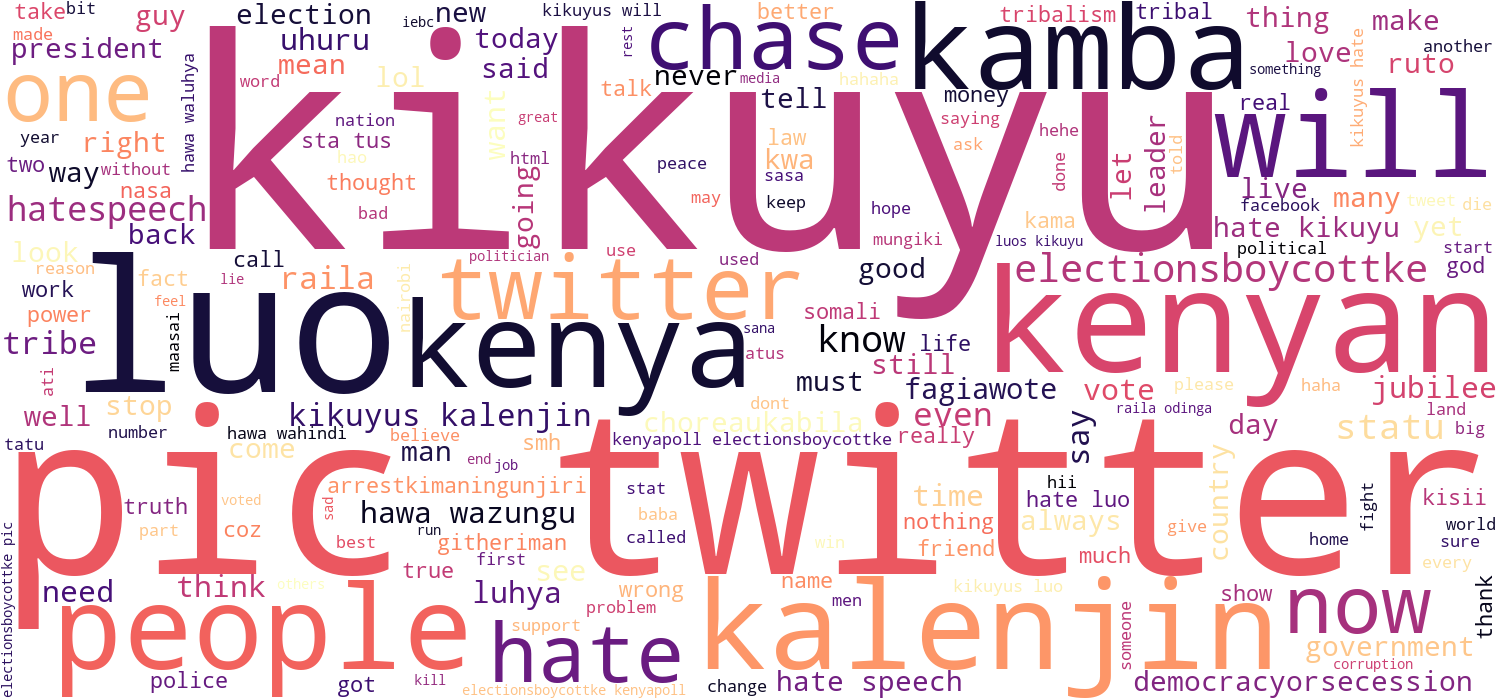

Top 10 frequent words:
kikuyus: 7571
twitter: 4969
hate: 2729
hawa: 2589
pic: 2423
luos: 2238
will: 2120
electionsboycottke: 2096
kalenjins: 1935
chase: 1747


In [28]:
# Ensure clean_text is string-typed
data["clean_text"] = data["clean_text"].fillna("").astype(str)
wordcloud_text = " ".join(data["clean_text"].tolist())
from PIL import Image
wordcloud = WordCloud(width=1500, height=700, background_color="white", colormap="magma").generate(wordcloud_text)

wordcloud_image = wordcloud.to_image()
display(wordcloud_image)

print("Top 10 frequent words:")
for word, count in top_words[:10]:
    print(f"{word}: {count}")

In [34]:
# Visualization 1: Top hashtags
import re
from collections import Counter

hashtags = []
for t in data['raw_text'].astype(str):
    hashtags.extend(re.findall(r'#+', t))
ht_freq = Counter([h.lower() for h in hashtags])
top_ht = ht_freq.most_common(20)
ht_df = pd.DataFrame(top_ht, columns=['hashtag','count'])

fig_ht = px.bar(ht_df.sort_values('count', ascending=True), x='count', y='hashtag', orientation='h', title='Top 20 Hashtags', color='count', color_continuous_scale='Plasma')
fig_ht.show()

print('Top hashtags:')
for h,c in top_ht[:10]:
    print(f'{h}: {c}')

Top hashtags:
#: 1818
##: 2


In [35]:
# Visualization 2: Top bigrams from cleaned tokens
from collections import Counter

def bigrams_from(tokens):
    return [' '.join((tokens[i], tokens[i+1])) for i in range(len(tokens)-1)] if len(tokens) > 1 else []

all_bigrams = []
for toks in data['tokens']:
    if isinstance(toks, list):
        all_bigrams.extend(bigrams_from(toks))

bigram_freq = Counter(all_bigrams)
top_bi = bigram_freq.most_common(20)
bi_df = pd.DataFrame(top_bi, columns=['bigram','count'])

fig_bi = px.bar(bi_df.sort_values('count', ascending=True), x='count', y='bigram', orientation='h', title='Top 20 Bigrams', color='count', color_continuous_scale='Viridis')
fig_bi.show()

print('Top bigrams:')
for b,c in top_bi[:10]:
    print(f'{b}: {c}')

Top bigrams:
pic twitter: 2395
hawa wazungu: 563
kikuyus kalenjins: 530
hate speech: 398
hate kikuyus: 356
sta tus: 234
hate luos: 231
kenyapoll electionsboycottke: 205
hawa waluhya: 196
kikuyus will: 171


## Summary of EDA Insights 

I explored this dataset for its signal and noise, and here are the most important takeaways in plain language:
- **What stood out:** many tweets are short, repetitive and strongly centered on a handful of political/ethnic terms (e.g., tribal names and campaign hashtags).

- **Noise vs signal:** tokens like `twitter`, `pic`, or short filler words appear frequently; removing or adding them to a domain stoplist improves clarity (I recommend adding `twitter`, `pic`, `now`, `lol` to `stop_words`).

- **Duplicate content:** a significant number of identical tweets were present; deduplication based on normalized `clean_text` is necessary to avoid over-counting repeated messages.

- **Hashtags & phrases:** the hashtag plot shows which campaign tags dominated conversation, while the bigrams reveal common multi-word mentions (useful for phrase-level features).

